In [1]:
import os
import re
import pandas as pd
import numpy as np

from Figures_paper import save_dir
# Import all functions from the required modules
from cessation_lag_module import *
print("Successfully loaded all modules")

loaded defined RR values
Successfully loaded Cessation Lag functions
Successfully loaded all modules


In [2]:
CESSATION_LAGS_DIR = r"data\2-output-data\Cessation_lags"
#function for cleaning lag sheets
import re
def _normalize_outcome_text(outcome_text: str) -> str:
    """
    Clean and normalize health outcome names for better matching.
    Examples:
        "Hypertension (18+)" -> "hypertension"
        "Type 2 Diabetes (45+)" -> "type 2 diabetes"
    """
    if pd.isna(outcome_text):
        return ""
    # Convert to lowercase and strip whitespace
    cleaned = str(outcome_text).strip().lower()
    # Remove age ranges and other parenthetical content: (18+), (0-17), etc.
    cleaned = re.sub(r"\([^)]*\)", "", cleaned)
    # Remove punctuation, keep only letters, numbers, and spaces
    cleaned = re.sub(r"[^0-9a-z\s]", " ", cleaned)
    # Collapse multiple spaces into one
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [3]:
from scipy.interpolate import CubicSpline, PchipInterpolator
# ---------------- HELPERS ----------------
def _norm_text(x: str) -> str:
    if "pd" not in globals():
        import pandas as pd  # noqa: F401
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = re.sub(r"\([^)]*\)", "", s)
    s = re.sub(r"[^0-9a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def lin_interp(v0, v1, y0, y1, y):
    if y1 == y0:
        return v0
    return v0 + (v1 - v0) * (y - y0) / (y1 - y0)


def interp_cubic_spline(v2019, v2030, v2050, year):
    """Smooth cubic spline interpolation - C2 continuous"""
    years = np.array([2019, 2030, 2050])
    values = np.array([v2019, v2030, v2050])
    cs = CubicSpline(years, values)
    return float(cs(year))


def interp_pchip_smooth(v2019, v2030, v2050, year):
    """
    PCHIP interpolation: smooth, shape-preserving, no overshoot.
    Better than linear for health/economic projections.
    """
    years = np.array([2019, 2030, 2050])
    values = np.array([v2019, v2030, v2050])

    if np.allclose(values, values[0]):
        return float(values[0])

    interpolator = PchipInterpolator(years, values)
    result = float(interpolator(year))
    return max(0.0, result)


def interp_piecewise(v2019, v2030, v2050, year):
    return interp_pchip_smooth(v2019, v2030, v2050, year)


def find_col(df, *candidates):
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None


def safe_sum(df, col):
    if col is None or col not in df.columns:
        return 0.0
    return pd.to_numeric(df[col], errors="coerce").fillna(0).sum()


def _discover_files(base_dir: str, stems: list[str], exts: tuple[str, ...] = (".csv", ".xlsx")) -> dict[str, str]:
    out = {}
    if not base_dir or not os.path.isdir(base_dir):
        return out
    try:
        entries = os.listdir(base_dir)
    except Exception:
        return out

    entries_l = {str(fn).lower(): fn for fn in entries}
    for stem in stems:
        stem_l = str(stem).lower()
        best = None
        for ext in exts:
            key = f"{stem_l}{ext}"
            if key in entries_l:
                best = os.path.join(base_dir, entries_l[key])
                break
        if best is None:
            # fallback: startswith match + ext
            cands = []
            for fn_l, fn in entries_l.items():
                if fn_l.startswith(stem_l) and any(fn_l.endswith(ext) for ext in exts):
                    cands.append(os.path.join(base_dir, fn))
            if cands:
                try:
                    cands = sorted(cands, key=lambda p: os.path.getmtime(p), reverse=True)
                except Exception:
                    pass
                best = cands[0]
        if best is not None and os.path.isfile(best):
            out[stem] = best
    return out


def _read_multiplier_file(path: str) -> pd.DataFrame:
    if not path or (not os.path.exists(path)):
        return pd.DataFrame()
    try:
        if str(path).lower().endswith(".xlsx"):
            dfx = pd.read_excel(path)
        else:
            dfx = pd.read_csv(path)
    except Exception:
        return pd.DataFrame()

    if not isinstance(dfx, pd.DataFrame) or dfx.empty:
        return pd.DataFrame()

    dfx = dfx.copy()
    dfx.columns = dfx.columns.astype(str).str.strip()
    return dfx


def _standardize_multiplier_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=[
            "scenario",
            "pollutant",
            "year",
            "cumulative_multiplier_lag_over_no_lag",
            "annual_multiplier_lag_over_no_lag",
            "endpoint",
            "endpoint_short",
            "endpoint_norm",
        ])

    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    scen_col = find_col(df, "scenario", "Scenario")
    pol_col = find_col(df, "pollutant", "Pollutant")
    yr_col = find_col(df, "year", "Year")
    cum_col = find_col(df, "cumulative_multiplier_lag_over_no_lag")
    ann_col = find_col(df, "annual_multiplier_lag_over_no_lag")

    ep_col = find_col(df, "endpoint", "health_outcome", "outcome")
    eps_col = find_col(df, "endpoint_short", "endpoint short", "outcome_short")

    if scen_col is None:
        df["scenario"] = np.nan
    else:
        df["scenario"] = df[scen_col]

    if pol_col is None:
        df["pollutant"] = np.nan
    else:
        df["pollutant"] = df[pol_col]

    if yr_col is None:
        df["year"] = np.nan
    else:
        df["year"] = pd.to_numeric(df[yr_col], errors="coerce")

    df = df.dropna(subset=["year"]).copy()
    df["year"] = df["year"].astype(int)

    if cum_col is None:
        df["cumulative_multiplier_lag_over_no_lag"] = np.nan
    else:
        df["cumulative_multiplier_lag_over_no_lag"] = pd.to_numeric(df[cum_col], errors="coerce")

    if ann_col is None:
        df["annual_multiplier_lag_over_no_lag"] = np.nan
    else:
        df["annual_multiplier_lag_over_no_lag"] = pd.to_numeric(df[ann_col], errors="coerce")

    if ep_col is None:
        df["endpoint"] = df.get("endpoint", np.nan)
    else:
        df["endpoint"] = df[ep_col]

    if eps_col is None:
        df["endpoint_short"] = df.get("endpoint_short", np.nan)
    else:
        df["endpoint_short"] = df[eps_col]

    df["scenario"] = df["scenario"].astype(str).str.strip()
    df["pollutant"] = df["pollutant"].astype(str).str.strip()
    df["endpoint_norm"] = df["endpoint"].astype(str).map(_norm_text)

    keep = [
        "scenario",
        "pollutant",
        "year",
        "cumulative_multiplier_lag_over_no_lag",
        "annual_multiplier_lag_over_no_lag",
        "endpoint",
        "endpoint_short",
        "endpoint_norm",
    ]
    for c in keep:
        if c not in df.columns:
            df[c] = np.nan
    return df[keep].copy()


# ---------------- MULTIPLIER LOADERS (NEW FILES) ----------------
_yearly_mort_df = None
_yearly_morb_df = {}

_MORT_STEMS = [
    "multiplier_lag_v_no_lag_AVOIDED__s3_ug_PM25_RH50_2010_2070",
    "multiplier_lag_v_no_lag_AVOIDED__s3_ug_NO2_2010_2070",
    "multiplier_lag_v_no_lag_AVOIDED__s2_ug_PM25_RH50_2010_2070",
    "multiplier_lag_v_no_lag_AVOIDED__s2_ug_NO2_2010_2070",
]
_MORB_STEMS_BY_POL = {
    "ug_PM25_RH50": "morbidity_multiplier_lag_v_no_lag_AVOIDED__ug_PM25_RH50_2019_2070",
    "ug_NO2": "morbidity_multiplier_lag_v_no_lag_AVOIDED__ug_NO2_2019_2070",
}


def _base_dir_for_multipliers() -> str:
    if "CESSATION_LAGS_DIR" in globals() and isinstance(CESSATION_LAGS_DIR, str) and CESSATION_LAGS_DIR.strip():
        return CESSATION_LAGS_DIR
    return r"data\2-output-data\Cessation_lags"


def _load_yearly_mort():
    global _yearly_mort_df
    if _yearly_mort_df is not None:
        return _yearly_mort_df

    base_dir = _base_dir_for_multipliers()
    paths = _discover_files(base_dir, _MORT_STEMS, exts=(".csv", ".xlsx"))
    dfs = []
    for stem in _MORT_STEMS:
        p = paths.get(stem)
        dfx = _standardize_multiplier_df(_read_multiplier_file(p)) if p else pd.DataFrame()
        if not dfx.empty:
            dfs.append(dfx)

    if not dfs:
        _yearly_mort_df = pd.DataFrame(columns=[
            "scenario",
            "pollutant",
            "year",
            "cumulative_multiplier_lag_over_no_lag",
            "annual_multiplier_lag_over_no_lag",
        ])
        return _yearly_mort_df

    out = pd.concat(dfs, ignore_index=True)
    out = out.drop_duplicates(subset=["scenario", "pollutant", "year"], keep="last").copy()
    _yearly_mort_df = out
    return _yearly_mort_df


def _load_yearly_morb(pol: str):
    pol = str(pol).strip()
    if pol in _yearly_morb_df:
        return _yearly_morb_df[pol]

    base_dir = _base_dir_for_multipliers()
    stem = _MORB_STEMS_BY_POL.get(pol)
    if stem is None:
        _yearly_morb_df[pol] = pd.DataFrame()
        return _yearly_morb_df[pol]

    paths = _discover_files(base_dir, [stem], exts=(".csv", ".xlsx"))
    p = paths.get(stem)
    dfb = _standardize_multiplier_df(_read_multiplier_file(p)) if p else pd.DataFrame()

    if not dfb.empty:
        # If pollutant is missing in file, enforce from input
        if (dfb["pollutant"].isna().all()) or (dfb["pollutant"].astype(str).str.strip().eq("").all()):
            dfb["pollutant"] = pol
        dfb["pollutant"] = dfb["pollutant"].astype(str).str.strip()

    _yearly_morb_df[pol] = dfb if isinstance(dfb, pd.DataFrame) else pd.DataFrame()
    return _yearly_morb_df[pol]


# ---------------- LOOKUPS ----------------
_lag_cache = {}


def _pick_multiplier_value(row: pd.Series) -> float:
    v_ann = pd.to_numeric(row.get("annual_multiplier_lag_over_no_lag", np.nan), errors="coerce")
    if np.isfinite(v_ann):
        return float(v_ann)
    v_cum = pd.to_numeric(row.get("cumulative_multiplier_lag_over_no_lag", np.nan), errors="coerce")
    if np.isfinite(v_cum):
        return float(v_cum)
    return 1.0


def get_mort_lag(sc: str, pol: str, year: int, use_lag: bool) -> float:
    if not use_lag:
        return 1.0
    key = ("mort", str(sc).strip(), str(pol).strip(), int(year))
    if key in _lag_cache:
        return _lag_cache[key]

    dfm = _load_yearly_mort()
    if dfm is None or dfm.empty:
        _lag_cache[key] = 1.0
        return 1.0

    sel = dfm[
        (dfm["scenario"].astype(str).str.strip() == str(sc).strip()) &
        (dfm["pollutant"].astype(str).str.strip() == str(pol).strip()) &
        (dfm["year"] == int(year))
        ]
    if sel.empty:
        _lag_cache[key] = 1.0
        return 1.0

    out = _pick_multiplier_value(sel.iloc[0])
    _lag_cache[key] = out if np.isfinite(out) else 1.0
    return _lag_cache[key]


def get_morb_lag(sc: str, pol: str, year: int, outcome: str, use_lag: bool) -> float:
    if not use_lag:
        return 1.0
    key = ("morb", str(sc).strip(), str(pol).strip(), int(year), _norm_text(outcome))
    if key in _lag_cache:
        return _lag_cache[key]

    dfb = _load_yearly_morb(pol)
    if dfb is None or dfb.empty:
        _lag_cache[key] = 1.0
        return 1.0

    outcome_norm = _norm_text(outcome)

    sel = dfb[
        (dfb["scenario"].astype(str).str.strip() == str(sc).strip()) &
        (dfb["pollutant"].astype(str).str.strip() == str(pol).strip()) &
        (dfb["year"] == int(year))
        ]
    if sel.empty:
        _lag_cache[key] = 1.0
        return 1.0

    # If endpoint info exists, try to match; otherwise just take first row for that year/scenario/pollutant
    if "endpoint_norm" in sel.columns and sel["endpoint_norm"].notna().any():
        exact = sel[sel["endpoint_norm"] == outcome_norm]
        if exact.empty:
            toks = [t for t in outcome_norm.split() if len(t) > 3]
            if toks:
                tokmatch = sel[sel["endpoint_norm"].astype(str).apply(lambda s: any(t in s for t in toks))]
            else:
                tokmatch = sel.iloc[0:0]
            chosen = tokmatch if not tokmatch.empty else sel
        else:
            chosen = exact
    else:
        chosen = sel

    out = _pick_multiplier_value(chosen.iloc[0])
    _lag_cache[key] = out if np.isfinite(out) else 1.0
    return _lag_cache[key]


In [4]:
# Task: Build an annual (2019–2050) interpolated economic summary using the NO_LAG values from
#       economic_summary_morbidity_sensitivity_new.csv (2030 & 2050), anchoring 2019 at 0,
#       then create a lag-adjusted version using yearly annual multipliers from the loaded lag logic,
#       and save as data/2-output-data/economic_summary_interpolated_2019_2050.csv

in_file = os.path.join("data", "2-output-data", "economic_summary_morbidity_sensitivity.csv")
out_file = os.path.join("data", "2-output-data", "economic_summary_interpolated_2019_2050.csv")

df_in = pd.read_csv(in_file)
df_in["Year"] = pd.to_numeric(df_in["Year"], errors="coerce")
df_in = df_in.dropna(subset=["Year"]).copy()
df_in["Year"] = df_in["Year"].astype(int)

required_cols = ["Scenario", "Pollutant", "Year", "Lag"]
for c in required_cols:
    if c not in df_in.columns:
        raise ValueError(f"Missing required column '{c}' in {in_file}")

if "Disease" not in df_in.columns:
    df_in["Disease"] = "TOTAL"

# Use NO_LAG rows as baseline health outcomes to interpolate
df_base = df_in[df_in["Lag"].astype(str).str.strip().eq("no_lag")].copy()
if df_base.empty:
    raise ValueError("No 'no_lag' rows found in input file; cannot build baseline for interpolation.")


# Patch/override the buggy _norm_text (previous version triggers UnboundLocalError on 'pd')
def _norm_text(x) -> str:
    if x is None or pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = re.sub(r"\([^)]*\)", "", s)
    s = re.sub(r"[^0-9a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


# Parse bracketed uncertainty strings into numeric triplets
def _parse_bracket_range(s):
    if pd.isna(s):
        return (0.0, 0.0, 0.0)
    s = str(s).strip()
    if "[" not in s or "]" not in s or "-" not in s:
        v = pd.to_numeric(str(s).replace(",", "").strip(), errors="coerce")
        v = 0.0 if not np.isfinite(v) else float(v)
        return (v, v, v)
    left, right = s.split("[", 1)
    central = pd.to_numeric(left.replace(",", "").strip(), errors="coerce")
    central = 0.0 if not np.isfinite(central) else float(central)
    rng = right.replace("]", "").strip()
    low_s, high_s = rng.split("-", 1)
    low = pd.to_numeric(low_s.replace(",", "").strip(), errors="coerce")
    high = pd.to_numeric(high_s.replace(",", "").strip(), errors="coerce")
    low = 0.0 if not np.isfinite(low) else float(low)
    high = 0.0 if not np.isfinite(high) else float(high)
    return (central, low, high)


def _format_bracket_range(c, l, u, decimals=0):
    c = 0.0 if not np.isfinite(c) else float(c)
    l = 0.0 if not np.isfinite(l) else float(l)
    u = 0.0 if not np.isfinite(u) else float(u)
    if decimals <= 0:
        return f"{c:,.0f} [{l:,.0f}-{u:,.0f}]"
    fmt = f"{{:,.{decimals}f}}"
    return f"{fmt.format(c)} [{fmt.format(l)}-{fmt.format(u)}]"


def _get_morb_mult_with_fallback(sc, pol_code, year, outcome):
    if not pol_code:
        return 1.0

    v = get_morb_lag(sc, pol_code, int(year), outcome=str(outcome), use_lag=True)
    v = float(v) if np.isfinite(v) else 1.0
    if (v != 1.0) and (v > 0):
        return v

    try:
        dfb = _load_yearly_morb(pol_code)
    except Exception:
        dfb = pd.DataFrame()

    if dfb is None or dfb.empty:
        return 1.0

    out_norm = _norm_text(outcome)
    sel = dfb[dfb["year"].astype(int) == int(year)].copy()
    if sel.empty:
        return 1.0

    scen_norm = str(sc).strip()
    scen_col = sel["scenario"].astype(str).str.strip() if "scenario" in sel.columns else pd.Series([""] * len(sel))
    sel = sel[(scen_col.eq(scen_norm)) | (scen_col.eq("")) | (scen_col.str.lower().isin(["nan", "none"]))].copy()
    if sel.empty:
        return 1.0

    if "endpoint_norm" in sel.columns and sel["endpoint_norm"].notna().any():
        exact = sel[sel["endpoint_norm"].astype(str) == out_norm]
        if exact.empty:
            toks = [t for t in out_norm.split() if len(t) > 3]
            if toks:
                tokmatch = sel[sel["endpoint_norm"].astype(str).apply(lambda s: any(t in s for t in toks))]
                chosen = tokmatch if not tokmatch.empty else sel
            else:
                chosen = sel
        else:
            chosen = exact
    else:
        chosen = sel

    vv = _pick_multiplier_value(chosen.iloc[0])
    vv = float(vv) if np.isfinite(vv) else 1.0
    return vv if vv > 0 else 1.0


range_cols = ["Avoided Cases", "Deaths Avoided", "YLL Avoided", "YLD Avoided"]
for rc in range_cols:
    if rc not in df_base.columns:
        df_base[rc] = np.nan

cost_cols = [
    "Direct Med Cost (M€)",
    "Direct Med Cost LCI (M€)",
    "Direct Med Cost UCI (M€)",
    "Intangible Cost YLL (M€)",
    "Intangible Cost YLL LCI (M€)",
    "Intangible Cost YLL UCI (M€)",
    "Intangible Cost YLD (M€)",
    "Intangible Cost YLD LCI (M€)",
    "Intangible Cost YLD UCI (M€)",
]
for cc in cost_cols:
    if cc not in df_base.columns:
        df_base[cc] = 0.0
    df_base[cc] = pd.to_numeric(df_base[cc], errors="coerce").fillna(0.0)

# Pollutant name -> pollutant code used in multipliers
pollutant_name_to_code = {"PM2.5": "ug_PM25_RH50", "NO2": "ug_NO2"}

years_full = list(range(2019, 2050 + 1))

rows_out = []
groups = df_base.groupby(["Scenario", "Pollutant", "Disease"], dropna=False)
for (sc, pol_name, dis_name), g in groups:
    g = g.sort_values("Year").copy()

    r2030 = g[g["Year"] == 2030]
    r2050 = g[g["Year"] == 2050]
    if r2030.empty or r2050.empty:
        continue

    r2030 = r2030.iloc[0]
    r2050 = r2050.iloc[0]

    # Baseline anchor at 2019 = 0 for avoided outcomes/costs
    base_anchor_2019 = {
        "Avoided Cases": (0.0, 0.0, 0.0),
        "Deaths Avoided": (0.0, 0.0, 0.0),
        "YLL Avoided": (0.0, 0.0, 0.0),
        "YLD Avoided": (0.0, 0.0, 0.0),
    }
    v2030 = {rc: _parse_bracket_range(r2030.get(rc, np.nan)) for rc in range_cols}
    v2050 = {rc: _parse_bracket_range(r2050.get(rc, np.nan)) for rc in range_cols}

    c2019 = {cc: 0.0 for cc in cost_cols}
    c2030 = {cc: float(pd.to_numeric(r2030.get(cc, 0.0), errors="coerce") or 0.0) for cc in cost_cols}
    c2050 = {cc: float(pd.to_numeric(r2050.get(cc, 0.0), errors="coerce") or 0.0) for cc in cost_cols}

    for y in years_full:
        # --- NO_LAG interpolated ---
        no_lag_metrics = {}
        for rc in range_cols:
            (c0, l0, u0) = base_anchor_2019[rc]
            (c1, l1, u1) = v2030[rc]
            (c2, l2, u2) = v2050[rc]
            ic = interp_piecewise(c0, c1, c2, y)
            il = interp_piecewise(l0, l1, l2, y)
            iu = interp_piecewise(u0, u1, u2, y)
            no_lag_metrics[rc] = (ic, il, iu)

        no_lag_costs = {}
        for cc in cost_cols:
            v0 = c2019[cc]
            v1 = c2030[cc]
            v2 = c2050[cc]
            no_lag_costs[cc] = interp_piecewise(v0, v1, v2, y)

        rows_out.append({
            "Scenario": sc,
            "Pollutant": pol_name,
            "Disease": dis_name,
            "Year": int(y),
            "Lag": "no_lag",
            "Lag factor used (mortality)": 1.0,
            "Lag factor used (morbidity)": 1.0,
            "Avoided Cases": _format_bracket_range(*no_lag_metrics["Avoided Cases"], decimals=0),
            "Deaths Avoided": _format_bracket_range(*no_lag_metrics["Deaths Avoided"], decimals=0),
            "YLL Avoided": _format_bracket_range(*no_lag_metrics["YLL Avoided"], decimals=0),
            "YLD Avoided": _format_bracket_range(*no_lag_metrics["YLD Avoided"], decimals=0),
            **no_lag_costs,
        })

        # --- CESSATION_LAG adjusted from NO_LAG using yearly multipliers ---
        pol_code = pollutant_name_to_code.get(str(pol_name).strip(), None)
        mort_mult = get_mort_lag(sc, pol_code, int(y), use_lag=True) if pol_code else 1.0
        if not np.isfinite(mort_mult) or mort_mult <= 0:
            mort_mult = 1.0

        morb_mult = _get_morb_mult_with_fallback(sc, pol_code, int(y), outcome=str(dis_name))
        if not np.isfinite(morb_mult) or morb_mult <= 0:
            morb_mult = 1.0

        lag_metrics = {}
        # Morbidity-driven
        for rc in ["Avoided Cases", "YLD Avoided"]:
            ic, il, iu = no_lag_metrics[rc]
            lag_metrics[rc] = (ic * morb_mult, il * morb_mult, iu * morb_mult)

        # Mortality-driven
        for rc in ["Deaths Avoided", "YLL Avoided"]:
            ic, il, iu = no_lag_metrics[rc]
            lag_metrics[rc] = (ic * mort_mult, il * mort_mult, iu * mort_mult)

        # Costs: split by YLD vs YLL categories; direct medical assumed morbidity-driven
        lag_costs = {}
        for cc in cost_cols:
            v = float(no_lag_costs[cc])
            if "YLL" in cc:
                lag_costs[cc] = v * mort_mult
            elif ("YLD" in cc) or ("Direct Med" in cc):
                lag_costs[cc] = v * morb_mult
            else:
                lag_costs[cc] = v

        rows_out.append({
            "Scenario": sc,
            "Pollutant": pol_name,
            "Disease": dis_name,
            "Year": int(y),
            "Lag": "cessation_lag",
            "Lag factor used (mortality)": float(mort_mult) if np.isfinite(mort_mult) else 1.0,
            "Lag factor used (morbidity)": float(morb_mult) if np.isfinite(morb_mult) else 1.0,
            "Avoided Cases": _format_bracket_range(*lag_metrics["Avoided Cases"], decimals=0),
            "Deaths Avoided": _format_bracket_range(*lag_metrics["Deaths Avoided"], decimals=0),
            "YLL Avoided": _format_bracket_range(*lag_metrics["YLL Avoided"], decimals=0),
            "YLD Avoided": _format_bracket_range(*lag_metrics["YLD Avoided"], decimals=0),
            **lag_costs,
        })

df_out = pd.DataFrame(rows_out)
df_out = df_out.sort_values(["Scenario", "Pollutant", "Disease", "Lag", "Year"]).reset_index(drop=True)
df_out.to_csv(out_file, index=False)

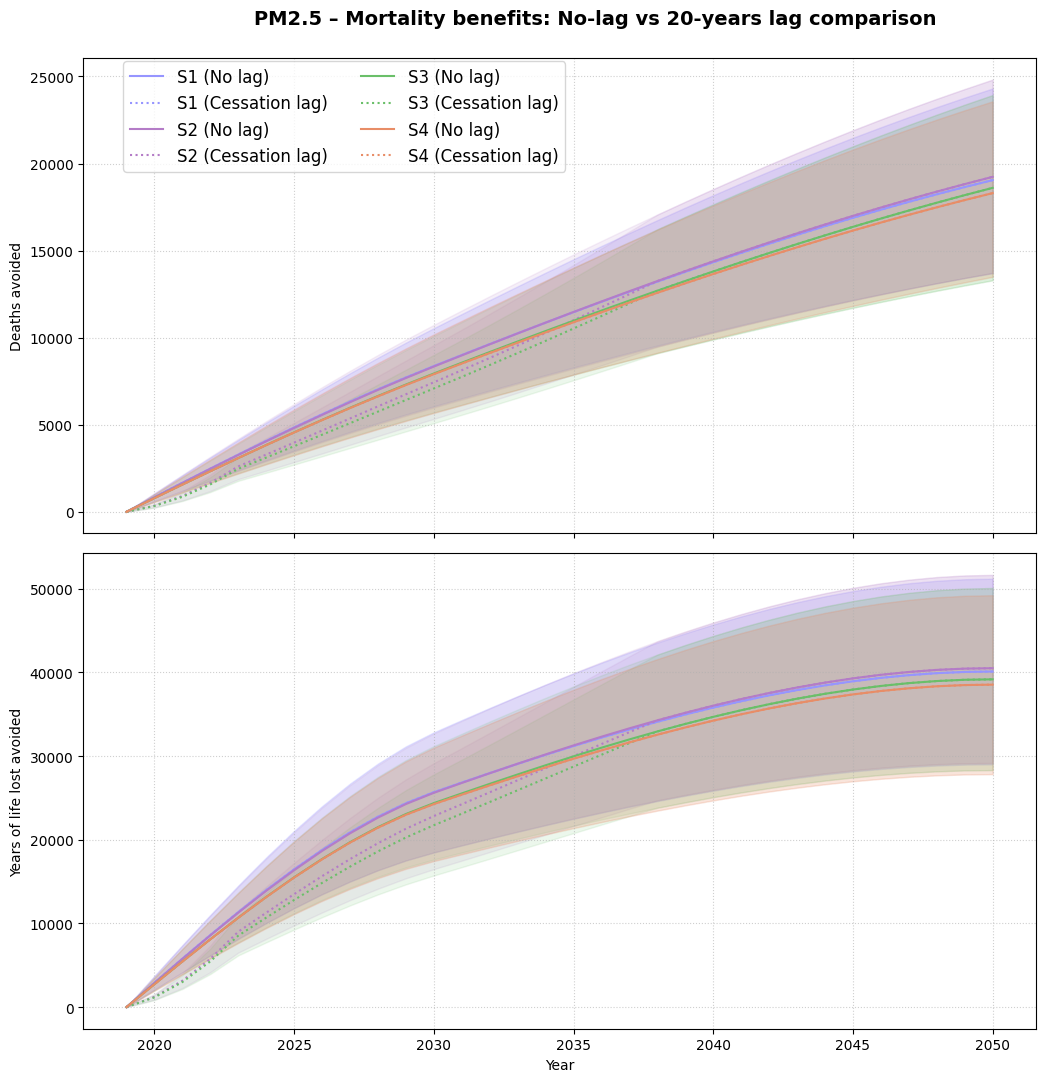

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= LOAD =================
df = pd.read_csv("data/2-output-data/economic_summary_interpolated_2019_2050.csv")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

# ================= FILTER =================
pollutant = "PM2.5"
df_mort = df[
    (df["Pollutant"] == pollutant) &
    (df["Disease"] == "All-cause mortality (main)")
    ].copy()


# ================= PARSE CENTRAL/CI =================
def parse_ci_column(dataframe, column):
    c, l, u = [], [], []
    for val in dataframe[column]:
        if pd.isna(val):
            c.append(0);
            l.append(0);
            u.append(0)
            continue

        val = str(val)
        if "[" not in val:
            v = float(val.replace(",", ""))
            c.append(v);
            l.append(v);
            u.append(v)
        else:
            center, rest = val.split("[", 1)
            lower, upper = rest.replace("]", "").split("-")
            c.append(float(center.replace(",", "")))
            l.append(float(lower.replace(",", "")))
            u.append(float(upper.replace(",", "")))
    return c, l, u


for metric in ["Deaths Avoided", "YLL Avoided"]:
    if f"{metric}_c" not in df_mort.columns:
        c, l, u = parse_ci_column(df_mort, metric)
        df_mort[f"{metric}_c"] = c
        df_mort[f"{metric}_l"] = l
        df_mort[f"{metric}_u"] = u

# ================= PLOTTING =================
fig, axes = plt.subplots(2, 1, figsize=(12, 11), sharex=True)

scenarios = ["s1", "s2", "s3", "s4"]
colors = {"s1": "#9695FF", "s2": "#B47CC7", "s3": "#6ABF69", "s4": "#E88D67"}
scenario_labels = {"s1": "S1", "s2": "S2", "s3": "S3", "s4": "S4"}
linestyles = {"no_lag": 'solid', "cessation_lag": "dotted"}

# -------- PANEL 1 & 2 --------
for ax, metric, ylabel in zip(
        axes[:2],
        ["Deaths Avoided", "YLL Avoided"],
        ["Deaths avoided", "Years of life lost avoided"]
):
    for sc in ["s1", "s2", "s3", "s4"]:
        for lag in ["no_lag", "cessation_lag"]:

            d = df_mort[
                (df_mort["Scenario"] == sc) &
                (df_mort["Lag"] == lag)
                ].sort_values("Year")

            if d.empty:
                continue

            label = f"{scenario_labels[sc]} ({'No lag' if lag == 'no_lag' else 'Cessation lag'})"

            ax.plot(
                d["Year"],
                d[f"{metric}_c"],
                color=colors[sc],
                linestyle=linestyles[lag],
                linewidth=1.5,
                label=label
            )

            ax.fill_between(
                d["Year"],
                d[f"{metric}_l"],
                d[f"{metric}_u"],
                color=colors[sc],
                alpha=0.12
            )

    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle=":", alpha=0.6)

# -------- FINISH --------
axes[-1].set_xlabel("Year")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.1, 0.94), ncol=2, frameon=True, fontsize=12)
fig.suptitle(f"{pollutant} – Mortality benefits: No-lag vs 20-years lag comparison",
    fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.0, 0.88, 0.98])
plt.show()
save_dir = "data/2-output-data/plots/"
save_png = os.path.join(save_dir, f"Temporal_progression_{pollutant}.png")
fig.savefig(save_png, dpi=300, bbox_inches="tight")
plt.close(fig)